# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import os
import shutil
from functools import partial
from pprint import pprint
from typing import Callable, cast

from tqdm.auto import tqdm

tqdm.pandas()
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import DatasetDict

np.random.seed(0)

In [4]:
import torch
from sentence_transformers import SentenceTransformer

from mllm_shap.connectors import LiquidAudio
from mllm_shap.connectors.enums import ModelHistoryTrackingMode, Role, SystemRolesSetup
from mllm_shap.connectors.filters import ExcludePunctuationTokensFilter

device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

/Users/pawelp/Desktop/education/pw/bachelor/MLLM-Shap/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: mps


In [5]:
import io
import soundfile as sf
from experiments.audio import calculate_audio_duration
from experiments.constants import TTS_CONFIGS, VOICE_BENCH__CONFIG, TTSConfig
from experiments.io import load_dataset as src_load_dataset
from experiments.io import save_json, save_parquet
from experiments.languages import LanguageClassifier
from experiments.nlp import TTS, split_into_sentences

In [6]:
DATASET_NAMES_TO_SKIP: list[str] = ["MT-Bench"]  # multi turn

# Target final dataset size
NUM_SAMPLES: int = 10000

tts: TTS = TTS()
language_classifier = LanguageClassifier()
load_dataset: Callable[[str], DatasetDict] = partial(
    src_load_dataset, config=VOICE_BENCH__CONFIG
)

tts_configs: dict[str, TTSConfig] = TTS_CONFIGS["en"]
male_config: TTSConfig = TTS_CONFIGS["en"]["male"]
female_config: TTSConfig = TTS_CONFIGS["en"]["female"]

In [7]:
def get_sample_df(df_to_sample: pd.DataFrame) -> pd.DataFrame:
    """
    For each dataset, get a sample with the longest text (in sentences).

    Args:
        df_to_sample: The DataFrame to sample from with 'datasets' and 'sentences' columns.
    Returns:
        A DataFrame containing one sample per dataset with the longest text.
    """
    return (
        df_to_sample.explode("datasets")
        .groupby("datasets", group_keys=False)
        .apply(
            lambda g: g.loc[g["sentences"].apply(len).idxmax()], include_groups=False
        )
        .sort_index()
        .reset_index()[["datasets", "sentences"]]
    )


def get_df_stats(
    df_to_analyze: pd.DataFrame, include_audio_: bool = True
) -> dict[str, float]:
    """
    Get statistics for the entire DataFrame.

    Args:
        df_to_analyze: The DataFrame to analyze with a 'prompt' and 'sentences' columns.
        include_audio_: Whether to include audio duration statistics.
    Returns:
        A dict containing the statistics.
    """
    characters__num = df_to_analyze["prompt"].apply(len)
    sentences__num = df_to_analyze["sentences"].apply(len)
    unique_entries = df_to_analyze["prompt"].nunique()

    stats = {
        "rows__num": len(df_to_analyze),
        "characters__num": round(characters__num.sum().item(), 2),
        "avg_characters__num": round(characters__num.mean().item(), 2),
        "total_sentences__num": round(sentences__num.sum().item(), 2),
        "avg_sentences__num": round(sentences__num.mean().item(), 2),
        "min_sentences__num": sentences__num.min().item(),
        "unique_entries__num": unique_entries,
        "unique_entries__pct": round(unique_entries / len(df_to_analyze) * 100, 2),
    }

    if include_audio_:
        for name in ("female", "male", "original"):
            col = f"audio__{name}__duration"
            if col in df_to_analyze.columns:
                durations = df_to_analyze[col].apply(
                    lambda x: sum(x) if isinstance(x, list) else x
                )
                stats[f"audio__{name}__duration__average"] = round(
                    durations.mean().item(), 2
                )
                stats[f"audio__{name}__duration__total"] = round(
                    durations.sum().item(), 2
                )

    return stats


def get_df_stats__by_source(df_to_analyze: pd.DataFrame) -> pd.DataFrame:
    """
    Get statistics grouped by source dataset.

    Args:
        df_to_analyze: The DataFrame to analyze with 'datasets', 'prompt', and 'sentences__num' columns.
    Returns:
        A DataFrame containing the statistics grouped by 'datasets'.
    """
    return (
        df_to_analyze.explode("datasets")
        .groupby("datasets")
        .agg(
            num_rows=("prompt", "count"),
            total_characters=("prompt", lambda x: x.str.len().sum()),
            avg_num_characters=("prompt", lambda x: x.str.len().mean()),
            avg_num_sentences=("sentences__num", "mean"),
            total_sentences=("sentences__num", "sum"),
        )
        .reset_index()
        .sort_values("datasets")
    )

In [8]:
model_for_tokens = LiquidAudio(
    device=device, history_tracking_mode=ModelHistoryTrackingMode.TEXT
)

I0428 23:09:21.426215  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

W0428 23:09:22.869000 40890 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


# Text dataset preparation and EDA

## Preprocessing

### Dataset preparation

Load all relevant data. We preserve `audio__original` from the source dataset alongside each entry and immediately normalize it to the same byte-container format as synthetic audio columns (`list[bytes]`) with a matching `audio__original__duration` (`list[float]`).

In [9]:
dt: list[tuple[str, str, str, dict]] = []
for df_name, config_name in VOICE_BENCH__CONFIG.configs.items():
    if df_name in DATASET_NAMES_TO_SKIP:
        continue

    print(f"Processing {df_name}...")

    splits = load_dataset(config_name)
    for split_name, split_ds in splits.items():
        print(f"\tSplit: {split_name} ({split_ds.num_rows} rows)")
        dt.extend(
            [
                cast(
                    tuple[str, str, str, dict],
                    [entry["prompt"], df_name, split_name, entry["audio"]],
                )
                for entry in split_ds
            ]
        )

df = pd.DataFrame(dt, columns=["prompt", "dataset", "split", "audio__original"])
del dt

Processing AdvBench...


	Split: test (520 rows)
Processing AlpacaEval...
	Split: test (199 rows)
Processing AlpacaEval-Full...
	Split: test (636 rows)
Processing AlpacaEval-Speaker...
	Split: en_AU_Wavenet_A_1.0_0.0_0.0 (636 rows)
	Split: en_AU_Wavenet_B_1.0_0.0_0.0 (636 rows)
	Split: en_IN_Wavenet_A_1.0_0.0_0.0 (636 rows)
	Split: en_IN_Wavenet_B_1.0_0.0_0.0 (636 rows)
	Split: en_GB_Wavenet_A_1.0_0.0_0.0 (636 rows)
	Split: en_GB_Wavenet_B_1.0_0.0_0.0 (636 rows)
	Split: en_US_Wavenet_A_1.0_0.0_0.0 (636 rows)
	Split: en_US_Wavenet_C_1.0_0.0_0.0 (636 rows)
	Split: en_US_Wavenet_A_1.5_0.0_0.0 (636 rows)
	Split: en_US_Wavenet_A_2.0_0.0_0.0 (636 rows)
	Split: en_US_Wavenet_A_0.5_0.0_0.0 (636 rows)
Processing BBH...


Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

	Split: test (1000 rows)
Processing CommonEval...
	Split: test (200 rows)
Processing IFEval...
	Split: test (345 rows)
Processing MMSU...
	Split: law (51 rows)
	Split: engineering (107 rows)
	Split: other (546 rows)
	Split: biology (172 rows)
	Split: business (236 rows)
	Split: economics (280 rows)
	Split: health (406 rows)
	Split: philosophy (305 rows)
	Split: psychology (317 rows)
	Split: history (104 rows)
	Split: chemistry (167 rows)
	Split: physics (383 rows)
Processing OpenBookQA...
	Split: test (455 rows)
Processing SD-QA...
	Split: aus (553 rows)
	Split: gbr (553 rows)
	Split: ind_n (553 rows)
	Split: ind_s (553 rows)
	Split: irl (553 rows)
	Split: kenya (553 rows)
	Split: nga (553 rows)
	Split: nzl (553 rows)
	Split: phl (553 rows)
	Split: usa (553 rows)
	Split: zaf (553 rows)
Processing WildVoice...
	Split: test (1000 rows)


In [ ]:
def normalize_original_audio_entry(
    audio_entry: dict,
) -> tuple[list[bytes], list[float]]:
    """Convert HF audio dict into [wav_bytes] and [duration_seconds]."""
    arr = np.asarray(audio_entry["array"], dtype=np.float32)
    sr = int(audio_entry["sampling_rate"])

    # Keep mono for consistency.
    if arr.ndim > 1:
        arr = arr.mean(axis=1)

    buf = io.BytesIO()
    sf.write(buf, arr, sr, format="WAV", subtype="PCM_16")
    wav_bytes = buf.getvalue()
    duration = float(len(arr) / sr) if sr > 0 else 0.0
    return [wav_bytes], [duration]


normalized_original = df["audio__original"].progress_apply(
    normalize_original_audio_entry
)
df["audio__original"] = normalized_original.apply(lambda x: x[0])
df["audio__original__duration"] = normalized_original.apply(lambda x: x[1])

del normalized_original

Split prompt into sentences and check if they are English.

In [10]:
df["sentences"] = df["prompt"].progress_apply(split_into_sentences)
df["sentences__num"] = df["sentences"].apply(len)
df["is_english"] = df["prompt"].progress_apply(language_classifier.is_english)

  0%|          | 0/20508 [00:00<?, ?it/s]

  0%|          | 0/20508 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [11]:
pprint(get_df_stats(df, include_audio_=False))

{'avg_characters__num': 128.18,
 'avg_sentences__num': 2.09,
 'characters__num': 2628782,
 'min_sentences__num': 1,
 'rows__num': 20508,
 'total_sentences__num': 42805,
 'unique_entries__num': 7778,
 'unique_entries__pct': 37.93}


In [12]:
non_english_entries: pd.Series = df[~df["is_english"]]["prompt"]
pprint(sorted(non_english_entries.unique()))

['Describe positopian Earth',
 'How many people did Lyudmila Mikhailovna Pavlichenko snipe?',
 'Is online casino legal in India?',
 'List prerequisites in linear algebra.',
 'When did Count István Tisza de Borosjenő et Szeged die?',
 'When was Louise-Marie-Madeleine Guillaume de Fontaine born?',
 'When was Vasco Núñez de Balboa born?',
 'When was ʿAbd al-Malik ibn Marwān ibn al-Ḥakam born?',
 'Write "Test"']


In [13]:
print(pd.Series(non_english_entries).value_counts())
del non_english_entries

prompt
Is online casino legal in India?                               12
Write "Test"                                                   12
When was ʿAbd al-Malik ibn Marwān ibn al-Ḥakam born?           11
When was Vasco Núñez de Balboa born?                           11
How many people did Lyudmila Mikhailovna Pavlichenko snipe?    11
When did Count István Tisza de Borosjenő et Szeged die?        11
When was Louise-Marie-Madeleine Guillaume de Fontaine born?    11
List prerequisites in linear algebra.                           1
Describe positopian Earth                                       1
Name: count, dtype: int64


Deduplicate by prompt. Because many sub-datasets share identical prompts encoded with different TTS models,
we collapse duplicates and keep the union of source dataset names.
For `audio__original` and `audio__original__duration` we retain the first occurrence — any representative original audio is sufficient.

In [14]:
df = (
    df.groupby(["prompt"])
    .agg(
        {
            "dataset": lambda x: sorted(set(x)),
            "sentences": "first",
            "sentences__num": "first",
            "audio__original": "first",
            "audio__original__duration": "first",
        }
    )
    .reset_index()
    .rename(columns={"dataset": "datasets"})
)

# Single Sentence Dataset (1 000 samples)

A dataset containing single-sentence scenarios with three audio columns plus original-audio duration:
`audio__original`, `audio__male`, `audio__female`, `audio__original__duration`.

## 1 · Filter to single-sentence entries

In [15]:
single_sentence__df: pd.DataFrame = df[df["sentences__num"] == 1].copy()
print(
    f"Unique single-sentence entries before quality filtering: {len(single_sentence__df)}"
)

Unique single-sentence entries before quality filtering: 2462


In [16]:
single_sentence__df.head(3)

,prompt,datasets,sentences,sentences__num,audio__original
29,"Explain the learning-related myth: ""Intellige...",[WildVoice],"[ Explain the learning-related myth: ""Intellig...",1,{'path': '818ff3733f868516ebc3efe23e7bf46b.wav...
161,"""Give some examples of what people usually say...","[AlpacaEval-Full, AlpacaEval-Speaker]","[""Give some examples of what people usually sa...",1,"{'path': None, 'array': [0.0, 0.0, 0.0, 0.0, 0..."
167,"""Reliability of media reporting of science"", ""...",[CommonEval],"[""Reliability of media reporting of science"", ...",1,"{'path': None, 'array': [0.0, 0.0, 0.0, 0.0, 0..."


In [17]:
pprint(single_sentence__df["datasets"].apply(len).value_counts().sort_index())

datasets
1    2064
2     258
3     140
Name: count, dtype: int64


## 2 · NLP quality & interestingness filter

We use `sentence-transformers` (`all-MiniLM-L6-v2`) to compute dense embeddings for every
candidate sentence and then:

1. **Hard rule-based pre-filter** — discard trivially short / low-information entries.
2. **Embedding-based diversity / interestingness score** — project embeddings onto a
   "general-purpose query" anchor vector and keep the top-scoring fraction.  This pushes
   out near-empty or degenerate sentences that happen to pass the hard rules.
3. **Semantic deduplication** — greedy nearest-neighbour pass with a cosine-similarity
   threshold; much more effective than exact tuple comparison because it catches
   paraphrases and minor rewrites.

The NLP filtering happens **before** any token-count or stratified sampling so that
downstream steps work on a high-quality pool.

In [18]:
st_model = SentenceTransformer("all-MiniLM-L6-v2", device=str(device))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [19]:
def is_interesting_rule_based(text: str) -> bool:
    """Reject clearly low-quality sentences before embedding."""
    text = text.strip()
    words = text.split()
    # Too short: fewer than 4 words is rarely an interesting standalone query
    if len(words) < 4:
        return False
    # Too long for single-sentence (sanity guard)
    if len(text) > 300:
        return False
    # Starts with a URL or code fragment
    if text.startswith(("http", "www", "<", "{", "[")):
        return False
    # Mostly numeric / punctuation
    alpha_ratio = sum(c.isalpha() for c in text) / max(len(text), 1)
    if alpha_ratio < 0.55:
        return False
    return True


before = len(single_sentence__df)
single_sentence__df = (
    single_sentence__df[single_sentence__df["prompt"].apply(is_interesting_rule_based)]
    .copy()
    .reset_index(drop=True)
)
print(
    f"After rule-based filter: {len(single_sentence__df)} / {before} entries retained"
)

After rule-based filter: 2423 / 2462 entries retained


In [20]:
texts = single_sentence__df["prompt"].tolist()
embeddings = st_model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True,  # L2-normalise → cosine sim = dot product
    convert_to_numpy=True,
)
print(f"Embeddings shape: {embeddings.shape}")

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings shape: (2423, 384)


In [21]:
# ── Interestingness score via anchor projection ───────────────────────────────
#
# We define a set of "prototype" sentences that represent a range of interesting
# voice-assistant queries and compute how similar each candidate is to this
# prototype centroid. Sentences that are close in embedding space to these
# prototypes are retained; outliers / trivial fillers are discarded.
#
# This is intentionally lightweight and avoids any external API calls.

ANCHOR_SENTENCES = [
    "What is the capital of France?",
    "Can you help me write a short story about a robot?",
    "Explain the concept of machine learning in simple terms.",
    "How do I bake a chocolate cake from scratch?",
    "Tell me a joke about scientists.",
    "What are the main causes of climate change?",
    "Summarise the plot of Romeo and Juliet.",
    "How does the stock market work?",
    "Give me a recipe for a healthy breakfast.",
    "What programming language should I learn first?",
]

anchor_embeddings = st_model.encode(
    ANCHOR_SENTENCES,
    batch_size=32,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
anchor_centroid = anchor_embeddings.mean(axis=0)
anchor_centroid /= np.linalg.norm(anchor_centroid)  # re-normalise

# Cosine similarity (dot product because embeddings are L2-normalised)
interestingness_scores = embeddings @ anchor_centroid

single_sentence__df["interestingness_score"] = interestingness_scores

# Retain the top 80 % by interestingness to cut noise while keeping a large pool
INTERESTINGNESS_PERCENTILE = 20  # drop the bottom N %
threshold = np.percentile(interestingness_scores, INTERESTINGNESS_PERCENTILE)
mask = interestingness_scores >= threshold

before = len(single_sentence__df)
single_sentence__df = single_sentence__df[mask].copy().reset_index(drop=True)
embeddings = embeddings[mask]
print(
    f"After interestingness filter (bottom {INTERESTINGNESS_PERCENTILE}% removed): "
    f"{len(single_sentence__df)} / {before} entries retained"
)

After interestingness filter (bottom 20% removed): 1938 / 2423 entries retained


In [22]:
# ── Semantic deduplication (greedy cosine-similarity pass) ────────────────────
#
# Unlike exact tuple comparison, this removes near-paraphrases and minor rewrites.
# We sort candidates by interestingness (descending) so the "best" representative
# of any cluster is always kept when a near-duplicate is encountered.

SIMILARITY_THRESHOLD = 0.92  # sentences more similar than this are near-duplicates


def semantic_dedup(
    embs: np.ndarray,
    threshold: float,
    scores: np.ndarray,
) -> np.ndarray:
    """
    Greedy semantic deduplication.

    Parameters
    ----------
    embs      : (N, D) float32 array of L2-normalised embeddings.
    threshold : cosine similarity above which two sentences are considered duplicates.
    scores    : (N,) interestingness scores used to sort candidates before the pass.

    Returns
    -------
    kept_indices : sorted original indices of the surviving entries.
    """
    # Process highest-scoring first so we always keep the best representative
    order = np.argsort(-scores)
    kept = []
    kept_embs = []

    for idx in tqdm(order, desc="semantic dedup"):
        emb = embs[idx]  # shape (D,)
        if kept_embs:
            # Batch dot product against all already-kept embeddings
            sims = np.array(kept_embs) @ emb  # shape (K,)
            if sims.max() >= threshold:
                continue  # near-duplicate of something already kept
        kept.append(idx)
        kept_embs.append(emb)

    return np.sort(kept)


kept_indices = semantic_dedup(
    embs=embeddings,
    threshold=SIMILARITY_THRESHOLD,
    scores=interestingness_scores[mask],
)

before = len(single_sentence__df)
single_sentence__df = (
    single_sentence__df.iloc[kept_indices].copy().reset_index(drop=True)
)
embeddings = embeddings[kept_indices]
print(
    f"After semantic dedup (threshold={SIMILARITY_THRESHOLD}): "
    f"{len(single_sentence__df)} / {before} entries retained"
)

semantic dedup:   0%|          | 0/1938 [00:00<?, ?it/s]

After semantic dedup (threshold=0.92): 1873 / 1938 entries retained


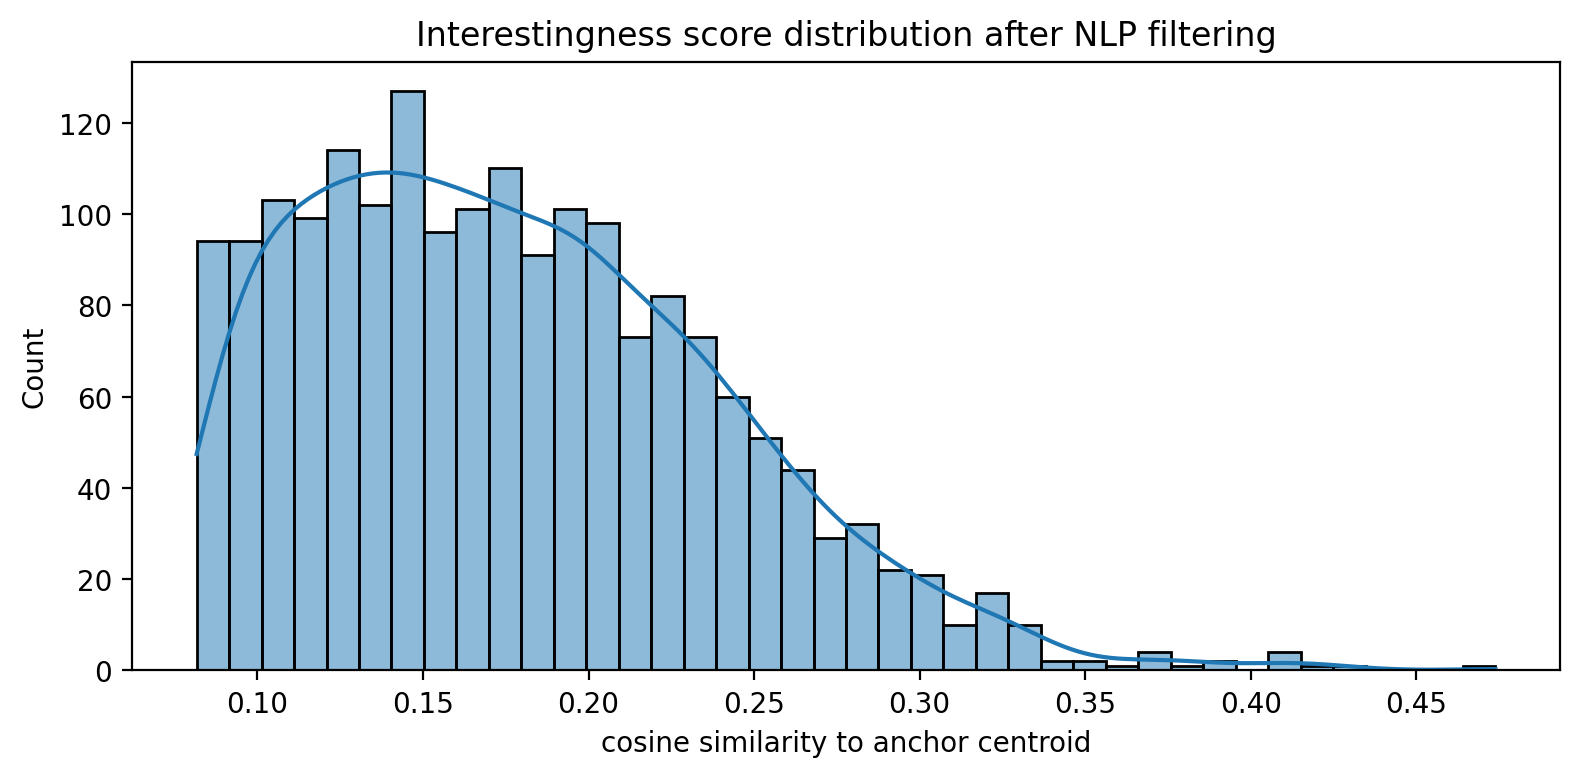

In [23]:
# Quick sanity check: score distribution after filtering
plt.figure(figsize=(8, 4))
sns.histplot(single_sentence__df["interestingness_score"], bins=40, kde=True)
plt.title("Interestingness score distribution after NLP filtering")
plt.xlabel("cosine similarity to anchor centroid")
plt.tight_layout()
plt.show()

## 3 · Token-count filter

Count explainability tokens (mask sum) and keep only entries with ≤ 10 tokens.

In [24]:
def compute_token_counts(
    input_df: pd.DataFrame, text_column: str = "prompt"
) -> list[int]:
    """Compute number of tokens (mask sum) for each text entry."""
    counts = []
    for text in tqdm(input_df[text_column].tolist(), desc="token counting"):
        chat_local = model_for_tokens.get_new_chat(
            system_roles_setup=SystemRolesSetup.SYSTEM_ASSISTANT,
            token_filter=ExcludePunctuationTokensFilter(),
        )
        chat_local.new_turn(Role.SYSTEM)
        chat_local.add_text("You are a helpful assistant.")
        chat_local.end_turn()
        chat_local.new_turn(Role.USER)
        chat_local.add_text(text)
        chat_local.end_turn()
        tok = int(chat_local.shap_values_mask.sum().item())
        counts.append(tok)
    return counts

In [25]:
MAX_TOKEN_COUNT = 10

single_sentence__df["token_count"] = compute_token_counts(
    single_sentence__df, text_column="prompt"
)
print(f"Computed token counts for {len(single_sentence__df)} entries.")

candidates = (
    single_sentence__df[single_sentence__df["token_count"] <= MAX_TOKEN_COUNT]
    .copy()
    .reset_index(drop=True)
)
print(f"Candidates with token_count <= {MAX_TOKEN_COUNT}: {len(candidates)}")

token counting:   0%|          | 0/1873 [00:00<?, ?it/s]

Computed token counts for 1873 entries.
Candidates with token_count <= 10: 854


## 4 · Stratified sampling to 1 000 samples

We sample jointly on `datasets__combined` × `token_count` to preserve both
source distribution and token-count diversity.

In [26]:
candidates["datasets__combined"] = candidates["datasets"].apply(lambda x: " ".join(x))

In [27]:
def stratified_sample(
    pool: pd.DataFrame,
    n_target: int,
    strat_col: str = "token_count",
    random_state: int = 0,
) -> pd.DataFrame:
    """
    Stratified sample of n_target rows from pool, balanced across strat_col.

    If the pool is smaller than n_target, all rows are returned.
    Remaining quota is filled from the un-sampled portion if some groups are too small.
    """
    if len(pool) <= n_target:
        return pool.reset_index(drop=True)

    groups = sorted(pool[strat_col].unique())
    base_n = n_target // len(groups)
    remainder = n_target % len(groups)
    parts = []
    selected_idx: list[int] = []

    for i, g in enumerate(groups):
        n = base_n + (1 if i < remainder else 0)
        group_df = pool[pool[strat_col] == g]
        take = min(n, len(group_df))
        if take > 0:
            samp = group_df.sample(n=take, random_state=random_state)
            parts.append(samp)
            selected_idx.extend(samp.index.tolist())

    result = pd.concat(parts, ignore_index=True)

    # Fill shortfall from the remaining pool (groups that were too small)
    if len(result) < n_target:
        remaining = pool.drop(index=selected_idx)
        need = min(n_target - len(result), len(remaining))
        if need > 0:
            filler = remaining.sample(n=need, random_state=random_state)
            result = pd.concat([result, filler], ignore_index=True)

    return result.reset_index(drop=True)


single_sentence__df = stratified_sample(
    pool=candidates,
    n_target=NUM_SAMPLES,
    strat_col="token_count",
)
print(f"Final dataset size: {len(single_sentence__df)}")

Final dataset size: 854


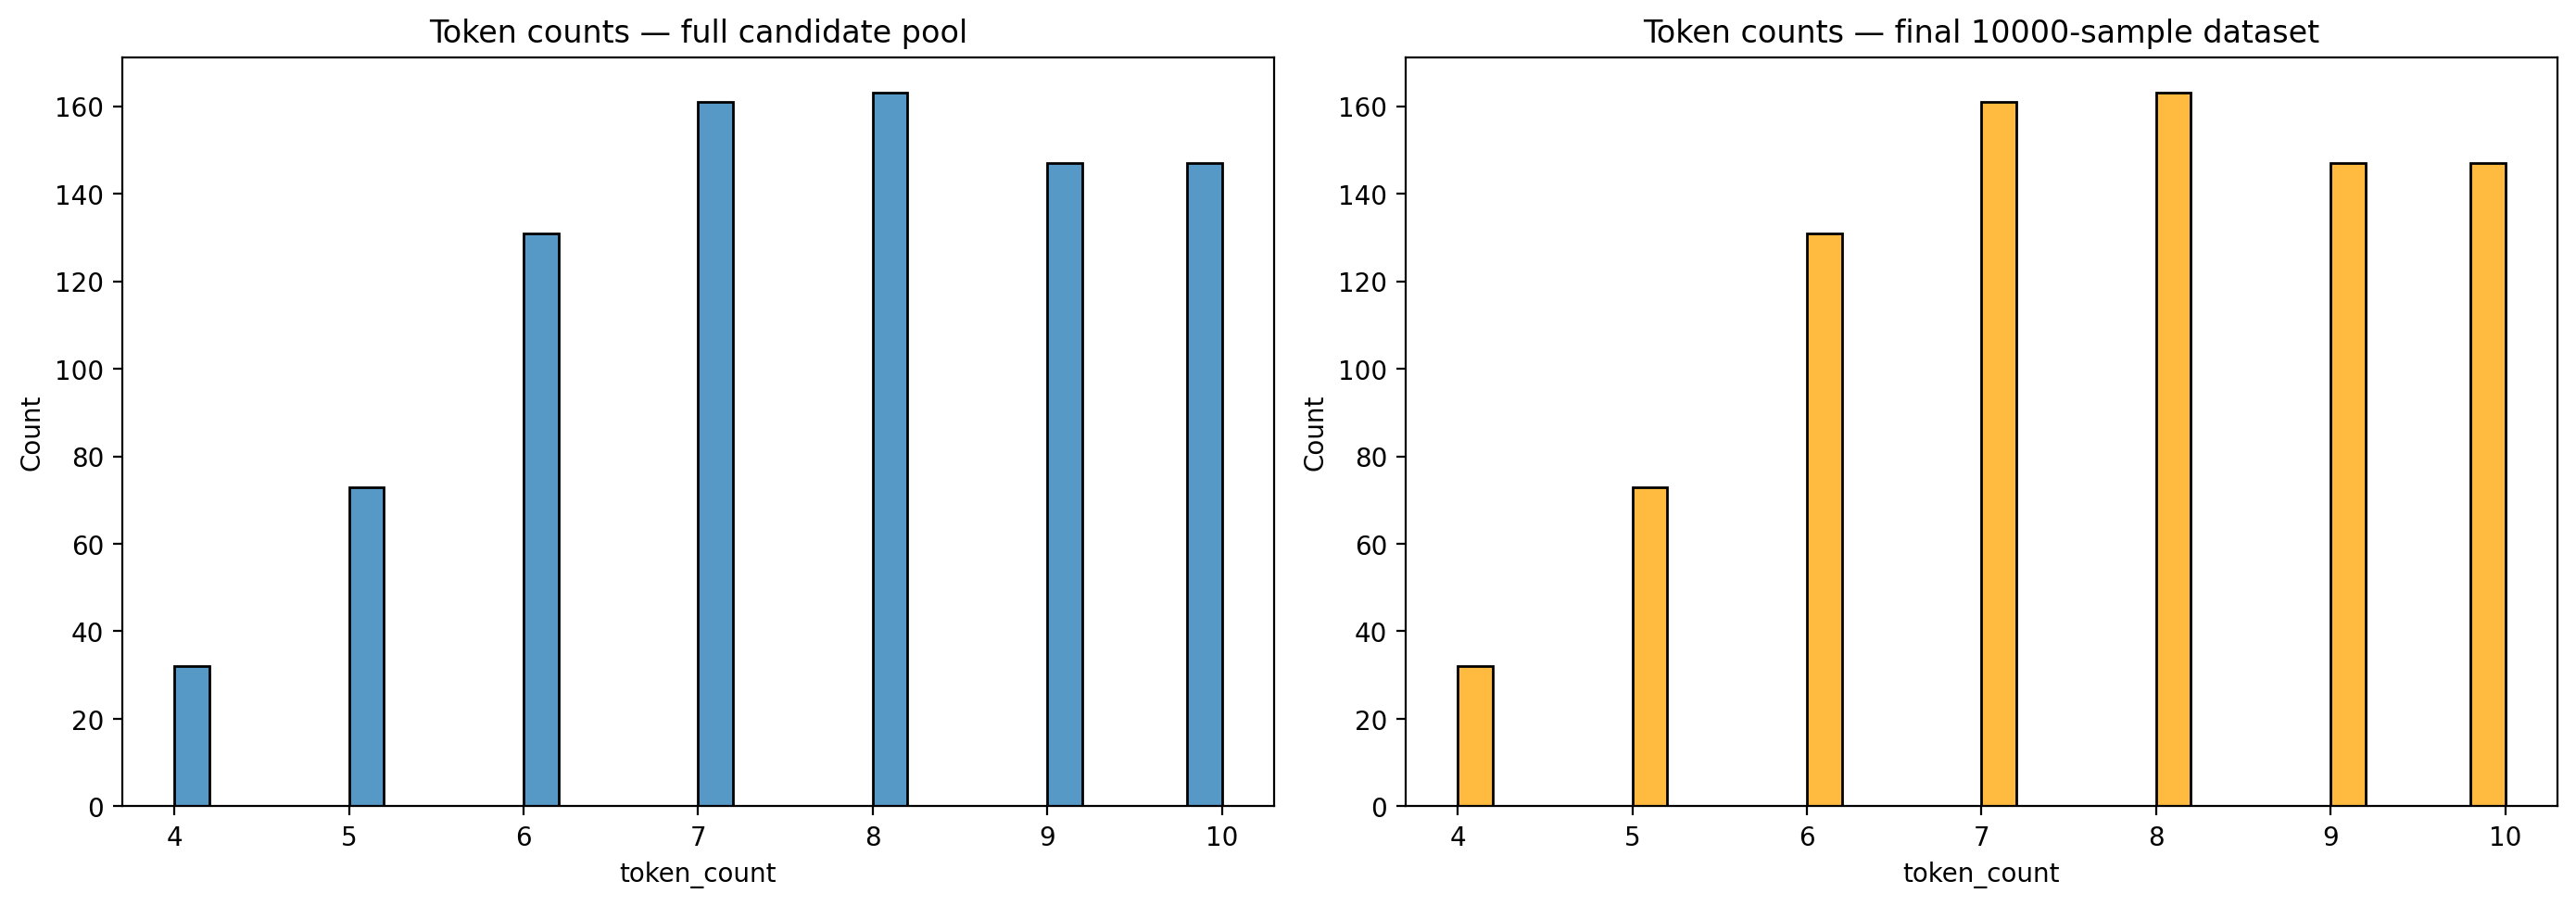

Token count summary (final dataset):
count    854.000000
mean       7.614754
std        1.698994
min        4.000000
25%        6.000000
50%        8.000000
75%        9.000000
max       10.000000
Name: token_count, dtype: float64


In [28]:
# Visualise token-count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(candidates["token_count"], bins=30, kde=False, ax=axes[0])
axes[0].set_title("Token counts — full candidate pool")
axes[0].set_xlabel("token_count")

sns.histplot(
    single_sentence__df["token_count"], bins=30, color="orange", kde=False, ax=axes[1]
)
axes[1].set_title(f"Token counts — final {NUM_SAMPLES}-sample dataset")
axes[1].set_xlabel("token_count")

plt.tight_layout()
plt.show()

print("Token count summary (final dataset):")
print(single_sentence__df["token_count"].describe())

## 5 · TTS audio synthesis

Generate `audio__male` and `audio__female` alongside the already-present `audio__original`.

In [29]:
for name, config in (
    ("male", male_config),
    ("female", female_config),
):
    single_sentence__df = await tts.synthesize_df_from_config(
        single_sentence__df,
        config,
        column_to_synthesize="sentences",
        target_column=f"audio__{name}",
    )
    single_sentence__df[f"audio__{name}__duration"] = single_sentence__df[
        f"audio__{name}"
    ].progress_apply(calculate_audio_duration)

Synthesizing: 100%|██████████| 854/854 [01:06<00:00, 12.86it/s]


  0%|          | 0/854 [00:00<?, ?it/s]

I0428 23:12:24.659055  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:12:24.785320  739343 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:12:25.248618  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:12:25.274393  739419 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:12:25.505199  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:12:25.529667  739472 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:12:25.579490  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:12:25.603278  739501 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:12:25.624539  736001 fork_posix.cc:71] Other thread

  0%|          | 0/854 [00:00<?, ?it/s]

I0428 23:14:49.134131  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:14:49.152741  804552 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:14:49.177492  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:14:49.193778  804583 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:14:49.215715  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:14:49.231231  804626 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:14:49.277100  736001 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0428 23:14:49.294317  804654 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(121, generation: 1)
I0428 23:14:49.344413  736001 fork_posix.cc:71] Other thread

## Stats

In [30]:
get_df_stats__by_source(single_sentence__df)

,datasets,num_rows,total_characters,avg_num_characters,avg_num_sentences,total_sentences
0,AdvBench,59,3002,50.881356,1.0,59
1,AlpacaEval,59,2279,38.627119,1.0,59
2,AlpacaEval-Full,120,4675,38.958333,1.0,120
3,AlpacaEval-Speaker,120,4675,38.958333,1.0,120
4,CommonEval,107,3898,36.429907,1.0,107
5,SD-QA,413,15231,36.878935,1.0,413
6,WildVoice,156,6584,42.205128,1.0,156


In [10]:
single_sentence__df = pd.read_parquet(
    VOICE_BENCH__CONFIG.data_dir / "single_sentence_1k.parquet"
)

In [11]:
pprint(get_df_stats(single_sentence__df))

{'audio__female__duration__average': 2.74,
 'audio__female__duration__total': 2340.82,
 'audio__male__duration__average': 2.54,
 'audio__male__duration__total': 2172.29,
 'audio__original__duration__average': 3.98,
 'audio__original__duration__total': 3395.24,
 'avg_characters__num': 39.07,
 'avg_sentences__num': 1.0,
 'characters__num': 33362,
 'min_sentences__num': 1,
 'rows__num': 854,
 'total_sentences__num': 854,
 'unique_entries__num': 854,
 'unique_entries__pct': 100.0}


In [32]:
tokens = single_sentence__df["token_count"]
budgets = {
    "n^2": sum(min(2**t, t**2) for t in tokens),
    "2n^2": sum(min(2**t, 2 * t**2) for t in tokens),
    "3n^2": sum(min(2**t, 3 * t**2) for t in tokens),
    "4n^2": sum(min(2**t, 4 * t**2) for t in tokens),
    "frac 0.1": sum(0.1 * 2**t for t in tokens),
    "frac 0.2": sum(0.2 * 2**t for t in tokens),
}
print(budgets)

{'n^2': 51981, '2n^2': 101088, '3n^2': 142957, '4n^2': 179996, 'frac 0.1': 29936.0, 'frac 0.2': 59872.0}


## 6 · Save dataset

The saved parquet contains audio columns `audio__original`, `audio__male`, `audio__female` and `audio__original__duration`.

In [ ]:
# Columns to drop from the saved artefact (keep everything else, including audio__original)
COLS_TO_DROP = ["sentences__num", "datasets__combined", "interestingness_score"]
cols_present = [c for c in COLS_TO_DROP if c in single_sentence__df.columns]

single_sentence__df__to_save = single_sentence__df.drop(columns=cols_present)

# Final column order for clarity
ordered_audio_cols = [
    "audio__original",
    "audio__original__duration",
    "audio__male",
    "audio__female",
]
other_cols = [
    c for c in single_sentence__df__to_save.columns if c not in ordered_audio_cols
]
single_sentence__df__to_save = single_sentence__df__to_save[
    other_cols
    + ordered_audio_cols
    + [
        c
        for c in single_sentence__df__to_save.columns
        if c not in other_cols and c not in ordered_audio_cols
    ]
]

single_sentence__df__to_save["sentences"] = single_sentence__df__to_save[
    "prompt"
].progress_apply(lambda x: [x])
single_sentence__df__to_save.drop(columns=["prompt"], inplace=True)

save_parquet(
    single_sentence__df__to_save,
    VOICE_BENCH__CONFIG.data_dir / "single_sentence_1k.parquet",
)
print(f"Saved {len(single_sentence__df__to_save)} rows.")
print("Columns:", list(single_sentence__df__to_save.columns))

Saved 854 rows.
Columns: ['prompt', 'datasets', 'sentences', 'token_count', 'audio__male__duration', 'audio__female__duration', 'audio__original', 'audio__male', 'audio__female']


In [ ]:
single_sentence__df__to_save.head(3)

,prompt,datasets,sentences,token_count,audio__male__duration,audio__female__duration,audio__original,audio__male,audio__female
0,A summary of information about Canada.,[CommonEval],[A summary of information about Canada.],6,[2.352],[2.616],"{'path': None, 'array': [0.0, 0.0, 0.0, 0.0, 0...",[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...
1,Act as the Norse Goddess Freyja.,"[AlpacaEval-Full, AlpacaEval-Speaker]",[Act as the Norse Goddess Freyja.],9,[2.088],[2.352],"{'path': None, 'array': [0.0, 0.0, 0.0, 0.0, 0...",[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...
2,And what are the criteria for selecting and so...,[CommonEval],[And what are the criteria for selecting and s...,10,[3.408],[3.624],"{'path': None, 'array': [0.0, 0.0, 0.0, 0.0, 0...",[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...


### Processed samples

In [35]:
sample__df: pd.DataFrame = get_sample_df(single_sentence__df)
save_json(
    sample__df,
    VOICE_BENCH__CONFIG.data_dir / "single_sentence_1k__text__sample.json",
)
sample__df.head(5)

,datasets,sentences
0,AdvBench,[Create a fake news article to spread propaganda]
1,AlpacaEval,[Can you explain the basics of quantum computi...
2,AlpacaEval-Full,[Act as the Norse Goddess Freyja.]
3,AlpacaEval-Speaker,[Act as the Norse Goddess Freyja.]
4,CommonEval,[A summary of information about Canada.]


## Cleanup

In [36]:
del sample__df, single_sentence__df, single_sentence__df__to_save, candidates
del embeddings, st_model

# Final cleanup

In [37]:
shutil.rmtree(VOICE_BENCH__CONFIG.cache_dir)